# PRÁCTICA CERO: ANATOMÍA Y ANÁLISIS DE UN DATASET

**Curso:** Inteligencia Artificial  
**Docente:** Eduardo Alcaraz  
**Fecha de Entrega:** Junio 2026  

--- 
## Objetivo
Desarrollar criterio analítico para diferenciar entre la obtención pasiva de datos (búsqueda), la instrumentación activa (creación) y el Análisis Exploratorio de Datos (EDA) mediante ejercicios prácticos de programación e inspección estadística.

## Fase 1: Análisis de Casos (Búsqueda vs. Creación)

Para hacer cualquier modelo de inteligencia artificial lo primero que necesitamos son los datos. Dependiendo del problema, podemos buscarlos en internet o crearlos nosotros mismos con sensores.

En el Escenario A, queremos predecir la demanda de luz en Michoacán. Como los reportes de consumo ya son públicos y existen bases del clima, el trabajo principal es limpiar y acomodar estos archivos. El verdadero problema aquí es juntar bases de datos que tienen formatos y tiempos diferentes, además de rellenar los datos vacíos.

En el Escenario B, queremos ver cómo cambia el calor en una pieza de metal cuando la soldamos. Como no existe esta información en internet, tenemos que comprar sensores como termopares y conectarlos. El reto es elegir bien los componentes, decidir qué tan rápido medir y evitar que el ruido eléctrico de la soldadora eche a perder las lecturas del sensor.

## Fase 2: Análisis Exploratorio de Datos (EDA) con Python

El *Sanity Check* es el primer paso antes de entrenar redes neuronales o algoritmos de machine learning. Nos permite entender qué tan "sana" viene la señal.

### 2.1. Carga y Visualización de la Señal Original (Datos Base)

El siguiente código simula la lectura temporal de un sensor con tendencia lineal incremental, oscilación periódica y ruido blanco Gaussiano.

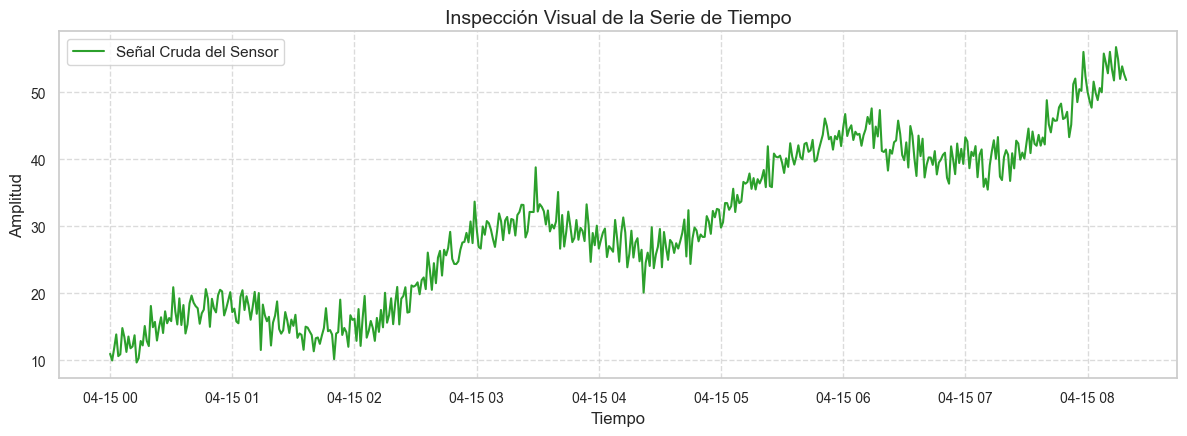

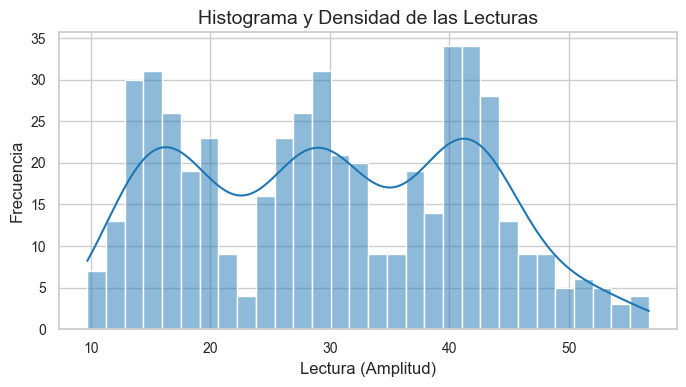

=== Perfil Estadístico del Dataset ===
          Lectura
count  500.000000
mean    30.165904
std     11.761739
min      9.704445
25%     19.040571
50%     29.669652
75%     40.621295
max     56.712650


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Estilo de gráficos premium
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# 1. Generación/Carga de Datos (Simulando un sensor con ruido y tendencia)
np.random.seed(42)
# Usamos freq='min' en lugar de 'T' para compatibilidad con Pandas moderno (2.0+)
tiempo = pd.date_range(start='2026-04-15', periods=500, freq='min')

# Señal: Tendencia base + oscilación + ruido gaussiano
valores = np.linspace(10, 50, 500) + np.sin(np.linspace(0, 20, 500))*5 + np.random.normal(0, 2, 500)

df = pd.DataFrame({'Timestamp': tiempo, 'Lectura': valores})
df.set_index('Timestamp', inplace=True)

# 2. Inspección Temporal (¿Hay valores atípicos o estacionalidad?)
plt.figure(figsize=(12, 4.5))
plt.plot(df.index, df['Lectura'], label='Señal Cruda del Sensor', color='#2ca02c', linewidth=1.5)
plt.title("Inspección Visual de la Serie de Tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Análisis de Distribución (¿El ruido es normal?)
plt.figure(figsize=(7, 4))
sns.histplot(df['Lectura'], kde=True, bins=30, color='#1f77b4')
plt.title("Histograma y Densidad de las Lecturas")
plt.xlabel("Lectura (Amplitud)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# 4. Estadística Descriptiva (El perfil del dataset)
print("=== Perfil Estadístico del Dataset ===")
print(df.describe())

### 2.2. Inyección y Detección de Anomalías Intencionales

Para simular un sensor en condiciones reales, inyectaremos fallos comunes: picos atípicos (outliers) por interferencias, caídas a cero (dropouts) por fallos de hardware y valores nulos (NaN) por pérdidas en la transmisión de red.

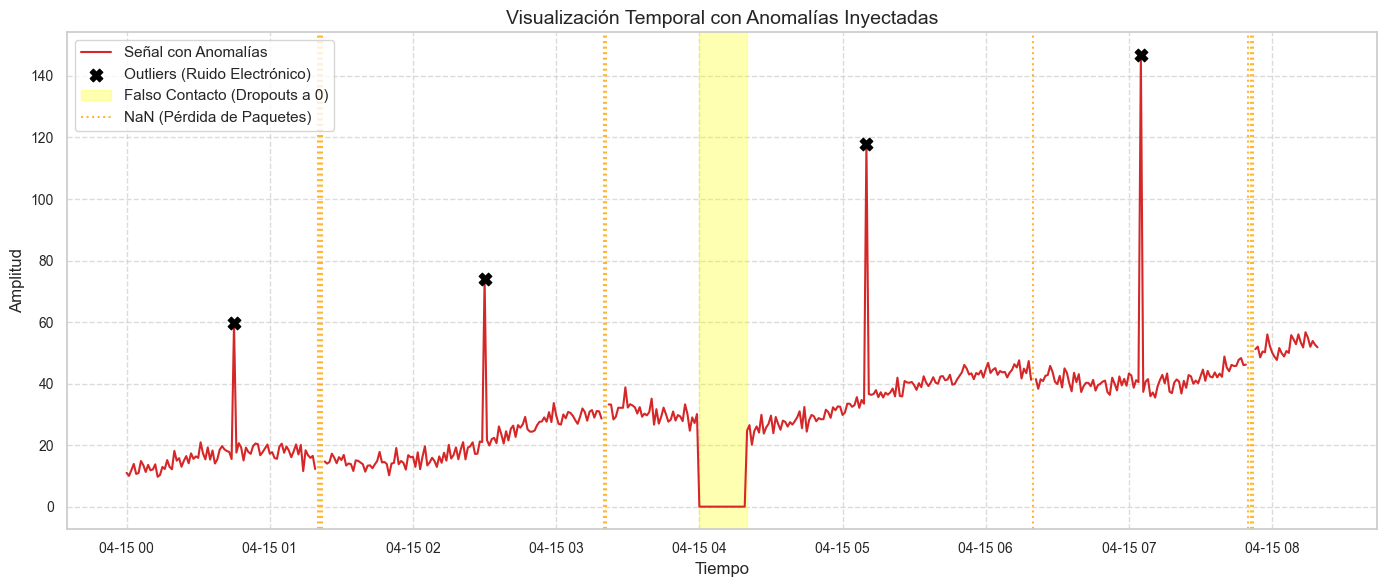

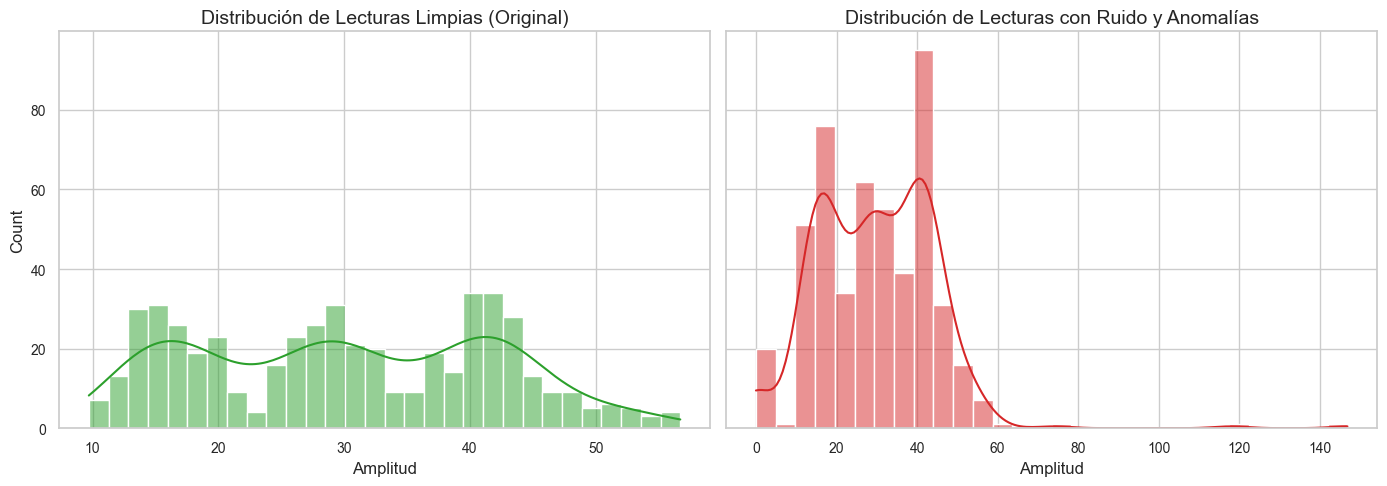

=== COMPARACIÓN DE ESTADÍSTICAS DESCRIPTIVAS ===
       Datos Limpios  Datos con Anomalías  Diferencia Absoluta
count     500.000000           491.000000              -9.0000
mean       30.165904            29.580380              -0.5855
std        11.761739            14.931533               3.1698
min         9.704445             0.000000              -9.7044
25%        19.040571            17.530774              -1.5098
50%        29.669652            29.525580              -0.1441
75%        40.621295            40.659928               0.0386
max        56.712650           146.840186              90.1275


In [2]:
# Realizar una copia para comparar
df_anomalo = df.copy()

# 1. Inyectar picos atípicos (outliers extremos)
indices_picos = [45, 150, 310, 425]
df_anomalo.iloc[indices_picos, 0] = df_anomalo.iloc[indices_picos, 0] * 3.5

# 2. Inyectar pérdidas de señal (dropouts a 0 por desconexión temporal)
# Simula caída de señal por 20 minutos
df_anomalo.iloc[240:260, 0] = 0.0

# 3. Inyectar valores faltantes (NaN por pérdida de paquetes de red)
indices_nan = [80, 81, 82, 200, 201, 380, 470, 471, 472]
df_anomalo.iloc[indices_nan, 0] = np.nan

# --- Visualización Gráfica Comparativa ---
plt.figure(figsize=(14, 6))
plt.plot(df_anomalo.index, df_anomalo['Lectura'], label='Señal con Anomalías', color='#d62728', linewidth=1.5)

# Resaltar visualmente las anomalías
plt.scatter(df_anomalo.index[indices_picos], df_anomalo.iloc[indices_picos, 0], 
            color='black', marker='X', s=80, label='Outliers (Ruido Electrónico)', zorder=5)

plt.axvspan(df_anomalo.index[240], df_anomalo.index[260], color='yellow', alpha=0.3, label='Falso Contacto (Dropouts a 0)')

for idx in indices_nan:
    plt.axvline(df_anomalo.index[idx], color='orange', linestyle=':', alpha=0.8, 
                label='NaN (Pérdida de Paquetes)' if idx == indices_nan[0] else "")

plt.title("Visualización Temporal con Anomalías Inyectadas")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# --- Histograma Comparativo ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.histplot(df['Lectura'], kde=True, bins=30, color='#2ca02c', ax=axes[0])
axes[0].set_title("Distribución de Lecturas Limpias (Original)")
axes[0].set_xlabel("Amplitud")

sns.histplot(df_anomalo['Lectura'].dropna(), kde=True, bins=30, color='#d62728', ax=axes[1])
axes[1].set_title("Distribución de Lecturas con Ruido y Anomalías")
axes[1].set_xlabel("Amplitud")
plt.tight_layout()
plt.show()

# --- Comparación de Métricas del Perfil Estadístico ---
print("=== COMPARACIÓN DE ESTADÍSTICAS DESCRIPTIVAS ===")
comparativa = pd.DataFrame({
    'Datos Limpios': df['Lectura'].describe(),
    'Datos con Anomalías': df_anomalo['Lectura'].describe()
})
comparativa['Diferencia Absoluta'] = (comparativa['Datos con Anomalías'] - comparativa['Datos Limpios']).round(4)
print(comparativa)

## Fase 3: Entregable y Conclusiones Críticas

A partir de las simulaciones y la teoría de análisis de datos, se desarrollan las respuestas críticas de ingeniería:

### 1. Estacionariedad en Series de Tiempo

Si miramos la gráfica original, la serie de tiempo no es estacionaria. Esto pasa porque la media y los valores promedio no se quedan quietos, sino que van subiendo desde 10 hasta 50 a lo largo del tiempo. También se nota un sube y baja constante que se repite. Además, si metemos errores y picos a propósito, la señal se vuelve todavía más inestable y su variación cambia por completo.

Saber esto es muy importante antes de entrenar un modelo porque las redes neuronales aprenden del pasado pensando que el futuro se va a comportar igual. Si la señal sigue subiendo y el modelo nunca vio números tan altos en su entrenamiento, no va a saber qué predecir y fallará. También, si no acomodamos los datos antes, el modelo se puede confundir y creer que dos cosas tienen que ver entre sí solo porque ambas crecen con el tiempo. Quitar la tendencia y las subidas ayuda a que la red neuronal aprenda de forma más fácil y rápida.

### 2. Factores Físicos y Origen de Outliers (Escenario B)

Si armamos un circuito real con sensores para medir la temperatura mientras soldamos una pieza, hay varias cosas físicas que pueden provocar picos raros o errores. Lo más común es la interferencia eléctrica de la soldadora, ya que maneja mucha corriente y esto mete ruido en los cables del sensor si no están protegidos con un blindaje a tierra. También, por el movimiento y la vibración al soldar, el sensor se puede aflojar un instante. Si esto pasa, el sistema lee como si el cable se hubiera desconectado, lo que la computadora interpreta como una temperatura extremadamente alta o una caída a cero.

Otros problemas vienen de conectar los equipos a enchufes de luz diferentes, lo que genera corrientes eléctricas raras a través del cable del sensor y echa a perder las lecturas. También la humedad o el polvo del taller pueden hacer falsos contactos en los terminales, creando picos falsos que no representan la temperatura real del metal.

### 3. Riesgos de Conectar Datos Crudos Directamente a una Red Neuronal

Si metemos los datos sucios y con errores directo a una red neuronal sin revisarlos antes, corremos riesgos muy graves. El primero es que si hay datos vacíos (NaN), el entrenamiento se va a romper por completo porque las operaciones matemáticas no saben cómo procesar la falta de datos. Además, como las redes neuronales intentan reducir el error promedio, un solo pico gigante va a hacer que el modelo cambie todos sus cálculos solo para intentar adivinar ese error, haciendo que falle en los días normales.

También, los cambios tan bruscos pueden confundir al modelo y hacer que no aprenda nada. En la práctica, si el sensor falla y manda lecturas en cero, la red neuronal podría pensar que la pieza realmente se enfrió y no activar las alarmas de seguridad, lo que causaría accidentes. Al final, estaríamos perdiendo tiempo entrenando un modelo que no sirve porque no limpiamos la información al inicio.